# World Bank Data: Women's Barriers in the Labor Market — Latin America

In [8]:
import wbgapi as wb
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

## Countries and Indicators

In [9]:
LATAM = [
    "ARG", "BOL", "BRA", "CHL", "COL", "CRI", "CUB", "DOM",
    "ECU", "SLV", "GTM", "HND", "MEX", "NIC", "PAN", "PRY",
    "PER", "URY", "VEN",
]

# Years of interest
YEARS = range(2000, 2024)

# Indicators grouped by theme
INDICATORS = {
    # --- Labor force participation ---
    "SL.TLF.CACT.FE.ZS": "Labor force participation rate, female (% of female population 15+)",
    "SL.TLF.CACT.MA.ZS": "Labor force participation rate, male (% of male population 15+)",
    "SL.TLF.CACT.FM.ZS": "Ratio female-to-male labor force participation rate (%)",

    # --- Unemployment ---
    "SL.UEM.TOTL.FE.ZS": "Unemployment rate, female (% of female labor force)",
    "SL.UEM.TOTL.MA.ZS": "Unemployment rate, male (% of male labor force)",

    # --- Employment quality ---
    "SL.EMP.VULN.FE.ZS": "Vulnerable employment, female (% of female employment)",
    "SL.EMP.VULN.MA.ZS": "Vulnerable employment, male (% of male employment)",
    "SL.EMP.SELF.FE.ZS": "Self-employed, female (% of female employment)",
    "SL.EMP.MPYR.FE.ZS": "Employers, female (% of female employment)",
    "SL.EMP.WORK.FE.ZS": "Wage & salaried workers, female (% of female employment)",

    # --- Sectoral employment ---
    "SL.AGR.EMPL.FE.ZS": "Employment in agriculture, female (% of female employment)",
    "SL.IND.EMPL.FE.ZS": "Employment in industry, female (% of female employment)",
    "SL.SRV.EMPL.FE.ZS": "Employment in services, female (% of female employment)",

    # --- Education (access barrier) ---
    "SE.ADT.LITR.FE.ZS": "Literacy rate, adult female (% of females 15+)",
    "SE.SEC.ENRR.FE":    "School enrollment, secondary, female (gross %)",
    "SE.TER.ENRR.FE":    "School enrollment, tertiary, female (gross %)",

    # --- Reproductive & household burden ---
    "SP.DYN.TFRT.IN":    "Fertility rate, total (births per woman)",
    "SH.STA.MMRT":       "Maternal mortality ratio (per 100,000 live births)",

    # --- Legal & institutional ---
    "SG.GEN.PARL.ZS":    "Proportion of seats held by women in national parliaments (%)",
    "IC.FRM.FEMM.ZS":    "Firms with female top manager (% of firms)",
}

## Fetch data from World Bank API

In [10]:
def fetch_indicators(indicators: dict, countries: list, years) -> pd.DataFrame:
    """Fetch multiple WB indicators and return a tidy long-format DataFrame."""
    frames = []
    for code, label in indicators.items():
        try:
            df = wb.data.DataFrame(
                code,
                economy=countries,
                time=years,
                labels=True,      # adds human-readable country names
                skipBlanks=True,
            )
            # wb returns wide format: rows = countries, columns = years
            df = df.reset_index()
            df = df.melt(
                id_vars=["economy", "Country"],
                var_name="year",
                value_name="value",
            )
            df["indicator_code"] = code
            df["indicator_name"] = label
            frames.append(df)
        except Exception as e:
            print(f"Could not fetch {code}: {e}")

    result = pd.concat(frames, ignore_index=True)
    result["year"] = result["year"].str.replace("YR", "").astype(int)
    result = result.rename(columns={"economy": "country_code", "Country": "country_name"})
    return result[["country_code", "country_name", "year", "indicator_code", "indicator_name", "value"]]


df_raw = fetch_indicators(INDICATORS, LATAM, YEARS)
print(f"Shape: {df_raw.shape}")
df_raw.head(10)

Shape: (8711, 6)


,country_code,country_name,year,indicator_code,indicator_name,value
0,VEN,"Venezuela, RB",2000,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",47.91
1,URY,Uruguay,2000,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",48.99
2,PER,Peru,2000,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",53.53
3,PRY,Paraguay,2000,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",51.65
4,PAN,Panama,2000,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",44.85
5,NIC,Nicaragua,2000,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",35.88
6,MEX,Mexico,2000,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",38.87
7,HND,Honduras,2000,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",43.41
8,GTM,Guatemala,2000,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",46.08
9,SLV,El Salvador,2000,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",45.42


## Explore coverage

In [11]:
# Non-null observations per indicator
coverage = (
    df_raw.dropna(subset=["value"])
    .groupby(["indicator_code", "indicator_name"])
    .agg(non_null_obs=("value", "count"), countries=("country_code", "nunique"))
    .reset_index()
    .sort_values("non_null_obs", ascending=False)
)
coverage

,indicator_code,indicator_name,non_null_obs,countries
10,SL.EMP.VULN.MA.ZS,"Vulnerable employment, male (% of male employm...",456,19
11,SL.EMP.WORK.FE.ZS,"Wage & salaried workers, female (% of female e...",456,19
18,SL.UEM.TOTL.MA.ZS,"Unemployment rate, male (% of male labor force)",456,19
17,SL.UEM.TOTL.FE.ZS,"Unemployment rate, female (% of female labor f...",456,19
16,SL.TLF.CACT.MA.ZS,"Labor force participation rate, male (% of mal...",456,19
15,SL.TLF.CACT.FM.ZS,Ratio female-to-male labor force participation...,456,19
14,SL.TLF.CACT.FE.ZS,"Labor force participation rate, female (% of f...",456,19
13,SL.SRV.EMPL.FE.ZS,"Employment in services, female (% of female em...",456,19
12,SL.IND.EMPL.FE.ZS,"Employment in industry, female (% of female em...",456,19
19,SP.DYN.TFRT.IN,"Fertility rate, total (births per woman)",456,19


## Wide-format snapshot — latest available year per country

In [12]:
# For each country + indicator, keep the most recent non-null value
latest = (
    df_raw.dropna(subset=["value"])
    .sort_values("year", ascending=False)
    .groupby(["country_code", "country_name", "indicator_code"], as_index=False)
    .first()
)

# Pivot so each indicator is a column
df_wide = latest.pivot_table(
    index=["country_code", "country_name"],
    columns="indicator_code",
    values="value",
)
df_wide.columns.name = None
df_wide = df_wide.reset_index()
df_wide

,country_code,country_name,IC.FRM.FEMM.ZS,SE.ADT.LITR.FE.ZS,SE.SEC.ENRR.FE,SE.TER.ENRR.FE,SG.GEN.PARL.ZS,SH.STA.MMRT,SL.AGR.EMPL.FE.ZS,SL.EMP.MPYR.FE.ZS,SL.EMP.SELF.FE.ZS,SL.EMP.VULN.FE.ZS,SL.EMP.VULN.MA.ZS,SL.EMP.WORK.FE.ZS,SL.IND.EMPL.FE.ZS,SL.SRV.EMPL.FE.ZS,SL.TLF.CACT.FE.ZS,SL.TLF.CACT.FM.ZS,SL.TLF.CACT.MA.ZS,SL.UEM.TOTL.FE.ZS,SL.UEM.TOTL.MA.ZS,SP.DYN.TFRT.IN
0,ARG,Argentina,7.99,99.16,107.98,140.19,43.19,33.00,3.90,2.29,22.92,20.63,23.81,77.08,10.04,86.06,52.96,73.61,71.94,6.79,5.64,1.50
1,BOL,Bolivia,26.31,93.50,91.29,NaN,46.15,146.00,25.03,2.04,70.25,68.21,58.62,29.75,12.60,62.37,72.45,85.89,84.36,3.43,2.67,2.55
2,BRA,Brazil,19.37,94.88,108.78,71.93,17.54,67.00,3.49,2.99,25.59,22.60,30.27,74.41,10.59,85.91,53.20,72.77,73.12,9.70,6.61,1.62
3,CHL,Chile,4.52,96.33,104.63,114.00,35.48,10.00,3.19,1.71,23.50,21.79,21.27,76.50,10.72,86.09,51.96,72.88,71.30,9.36,8.76,1.17
4,COL,Colombia,24.60,95.62,103.59,64.32,28.88,59.00,5.99,1.83,43.11,41.28,45.51,56.89,13.15,80.86,51.83,68.05,76.17,11.87,7.97,1.65
5,CRI,Costa Rica,25.26,94.12,130.60,60.47,47.37,24.00,7.67,1.99,23.34,21.35,25.29,76.66,12.29,80.05,44.09,62.91,70.08,10.21,7.09,1.33
6,CUB,Cuba,NaN,96.35,96.35,65.25,55.74,35.00,6.79,3.24,18.90,15.66,21.86,81.10,11.04,82.16,41.16,62.66,65.69,1.86,1.65,1.44
7,DOM,Dominican Republic,21.19,94.21,79.05,77.18,27.89,124.00,1.34,2.02,31.55,29.53,44.18,68.45,8.16,90.50,52.48,68.66,76.43,8.44,3.51,2.24
8,ECU,Ecuador,22.91,95.72,94.18,76.07,43.07,55.00,27.56,1.59,59.65,58.06,42.13,40.35,9.53,62.91,52.52,68.46,76.72,4.35,2.92,1.82
9,GTM,Guatemala,18.46,78.76,48.25,30.53,20.00,94.00,16.12,2.20,54.46,52.26,29.12,45.54,19.24,64.64,38.14,46.59,81.86,3.03,2.01,2.31


## Save to CSV

In [13]:
import os

output_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data")
os.makedirs(output_dir, exist_ok=True)

df_raw.to_csv(os.path.join(output_dir, "wb_women_latam_long.csv"), index=False)
df_wide.to_csv(os.path.join(output_dir, "wb_women_latam_wide.csv"), index=False)

print("Saved:")
print(f"  Long format : {df_raw.shape}  → data/wb_women_latam_long.csv")
print(f"  Wide format : {df_wide.shape} → data/wb_women_latam_wide.csv")

Saved:
  Long format : (8711, 6)  → data/wb_women_latam_long.csv
  Wide format : (19, 22) → data/wb_women_latam_wide.csv


## Visualizations

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
COLORS = {"female": "#c2527a", "male": "#4a7fb5", "gap": "#e08c3a"}

# Helper: get latest value for a single indicator across all countries
def get_latest(indicator_code: str) -> pd.DataFrame:
    return (
        df_raw[df_raw["indicator_code"] == indicator_code]
        .dropna(subset=["value"])
        .sort_values("year", ascending=False)
        .groupby(["country_code", "country_name"], as_index=False)
        .first()
    )

### 1. Female vs Male Labor Force Participation — by country (latest year)

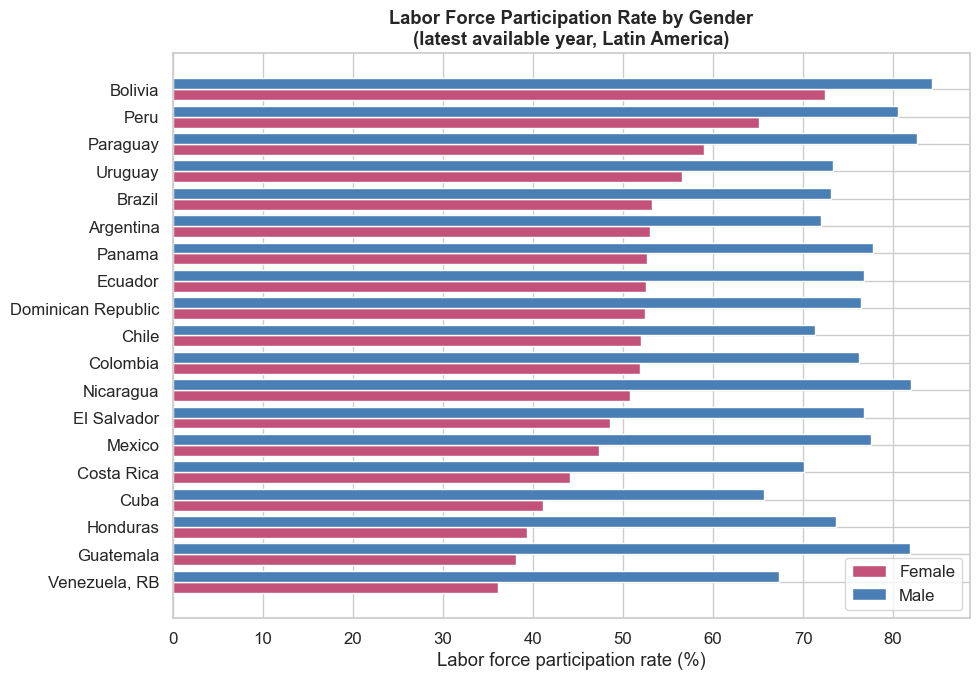

In [17]:
lfp_f = get_latest("SL.TLF.CACT.FE.ZS").set_index("country_name")["value"].rename("female")
lfp_m = get_latest("SL.TLF.CACT.MA.ZS").set_index("country_name")["value"].rename("male")
lfp = pd.concat([lfp_f, lfp_m], axis=1).dropna().sort_values("female")

fig, ax = plt.subplots(figsize=(10, 7))
y = range(len(lfp))
ax.barh([i - 0.2 for i in y], lfp["female"], height=0.4, color=COLORS["female"], label="Female")
ax.barh([i + 0.2 for i in y], lfp["male"],   height=0.4, color=COLORS["male"],   label="Male")
ax.set_yticks(list(y))
ax.set_yticklabels(lfp.index)
ax.set_xlabel("Labor force participation rate (%)")
ax.set_title("Labor Force Participation Rate by Gender\n(latest available year, Latin America)", fontweight="bold")
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.tight_layout()
plt.show()

### 2. Gender gap in labor force participation over time — regional trend

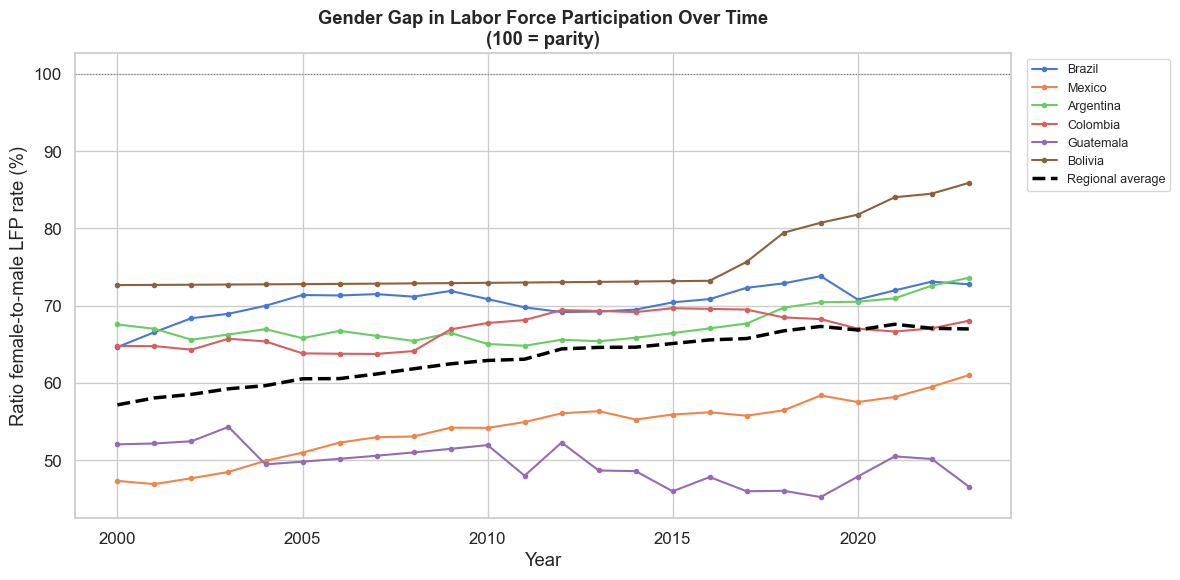

In [18]:
HIGHLIGHT = ["Brazil", "Mexico", "Argentina", "Colombia", "Guatemala", "Bolivia"]

gap_ts = (
    df_raw[df_raw["indicator_code"] == "SL.TLF.CACT.FM.ZS"]
    .dropna(subset=["value"])
    .groupby(["country_name", "year"])["value"]
    .mean()
    .reset_index()
)

# Regional average
regional_avg = gap_ts.groupby("year")["value"].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
for country in HIGHLIGHT:
    data = gap_ts[gap_ts["country_name"] == country]
    if not data.empty:
        ax.plot(data["year"], data["value"], marker="o", markersize=3, linewidth=1.5, label=country)

ax.plot(regional_avg["year"], regional_avg["value"], color="black",
        linewidth=2.5, linestyle="--", label="Regional average")
ax.axhline(100, color="grey", linewidth=0.8, linestyle=":")
ax.set_xlabel("Year")
ax.set_ylabel("Ratio female-to-male LFP rate (%)")
ax.set_title("Gender Gap in Labor Force Participation Over Time\n(100 = parity)", fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

### 3. Female vs Male Unemployment rate — scatter plot

In [ ]:
unem_f = get_latest("SL.UEM.TOTL.FE.ZS").set_index("country_name")["value"].rename("female")
unem_m = get_latest("SL.UEM.TOTL.MA.ZS").set_index("country_name")["value"].rename("male")
unem = pd.concat([unem_f, unem_m], axis=1).dropna()

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(unem["male"], unem["female"], color=COLORS["female"], s=80, zorder=3)
for country, row in unem.iterrows():
    ax.annotate(country, (row["male"], row["female"]),
                textcoords="offset points", xytext=(5, 3), fontsize=8)

# Parity line
lim = max(unem.max()) + 2
ax.plot([0, lim], [0, lim], color="grey", linewidth=1, linestyle="--", label="Parity (f = m)")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Male unemployment rate (%)")
ax.set_ylabel("Female unemployment rate (%)")
ax.set_title("Female vs Male Unemployment Rate\n(points above the line = women more unemployed)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### 4. Vulnerable employment — female vs male by country

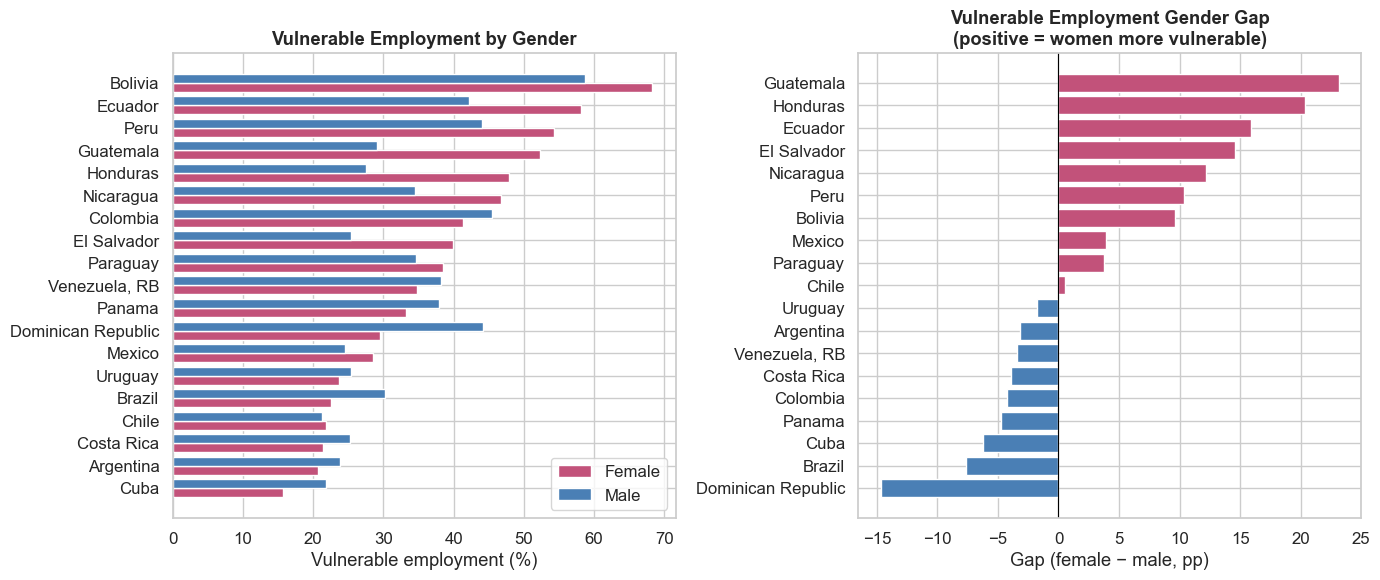

In [19]:
vuln_f = get_latest("SL.EMP.VULN.FE.ZS").set_index("country_name")["value"].rename("female")
vuln_m = get_latest("SL.EMP.VULN.MA.ZS").set_index("country_name")["value"].rename("male")
vuln = pd.concat([vuln_f, vuln_m], axis=1).dropna()
vuln["gap"] = vuln["female"] - vuln["male"]
vuln = vuln.sort_values("female")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: grouped bars
y = range(len(vuln))
axes[0].barh([i - 0.2 for i in y], vuln["female"], height=0.4, color=COLORS["female"], label="Female")
axes[0].barh([i + 0.2 for i in y], vuln["male"],   height=0.4, color=COLORS["male"],   label="Male")
axes[0].set_yticks(list(y))
axes[0].set_yticklabels(vuln.index)
axes[0].set_xlabel("Vulnerable employment (%)")
axes[0].set_title("Vulnerable Employment by Gender", fontweight="bold")
axes[0].legend()

# Right: gap (female − male)
gap_sorted = vuln["gap"].sort_values()
colors = [COLORS["female"] if v > 0 else COLORS["male"] for v in gap_sorted]
axes[1].barh(gap_sorted.index, gap_sorted.values, color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Gap (female − male, pp)")
axes[1].set_title("Vulnerable Employment Gender Gap\n(positive = women more vulnerable)", fontweight="bold")

plt.tight_layout()
plt.show()

### 5. Female sectoral employment composition — stacked bar

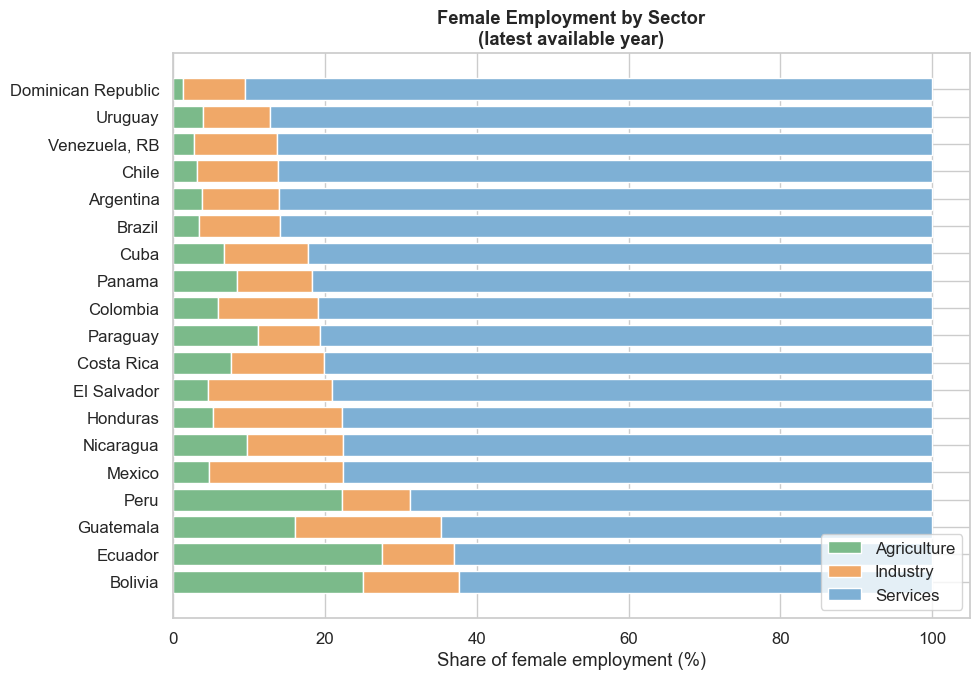

In [20]:
sector_codes = {
    "SL.AGR.EMPL.FE.ZS": "Agriculture",
    "SL.IND.EMPL.FE.ZS": "Industry",
    "SL.SRV.EMPL.FE.ZS": "Services",
}
sector_frames = {label: get_latest(code).set_index("country_name")["value"]
                 for code, label in sector_codes.items()}
sectors = pd.DataFrame(sector_frames).dropna()
sectors = sectors.sort_values("Services", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bottom = pd.Series(0, index=sectors.index)
palette = ["#7bba8a", "#f0a868", "#7eb0d5"]
for col, color in zip(["Agriculture", "Industry", "Services"], palette):
    ax.barh(sectors.index, sectors[col], left=bottom, color=color, label=col)
    bottom += sectors[col]

ax.set_xlabel("Share of female employment (%)")
ax.set_title("Female Employment by Sector\n(latest available year)", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 6. Women in parliament — evolution over time

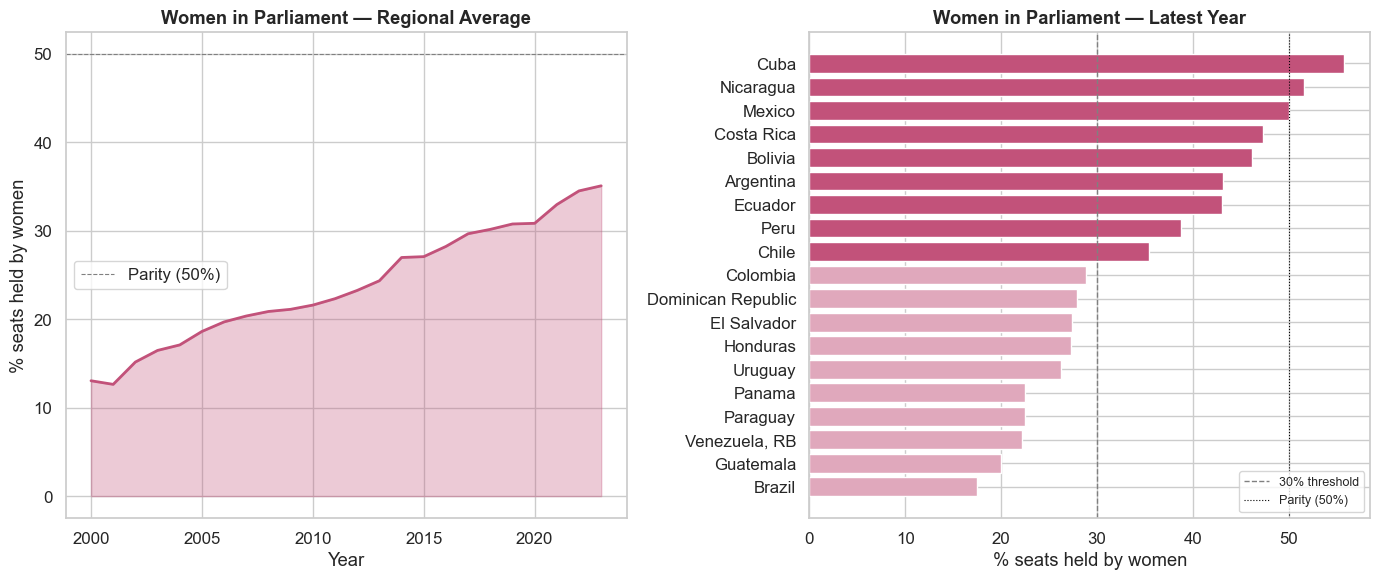

In [21]:
parl = (
    df_raw[df_raw["indicator_code"] == "SG.GEN.PARL.ZS"]
    .dropna(subset=["value"])
)
parl_avg = parl.groupby("year")["value"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: regional average over time
axes[0].fill_between(parl_avg["year"], parl_avg["value"], alpha=0.3, color=COLORS["female"])
axes[0].plot(parl_avg["year"], parl_avg["value"], color=COLORS["female"], linewidth=2)
axes[0].axhline(50, color="grey", linewidth=0.8, linestyle="--", label="Parity (50%)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("% seats held by women")
axes[0].set_title("Women in Parliament — Regional Average", fontweight="bold")
axes[0].legend()

# Right: latest value per country
latest_parl = (
    parl.sort_values("year", ascending=False)
    .groupby("country_name", as_index=False)
    .first()
    .sort_values("value")
)
bar_colors = [COLORS["female"] if v >= 30 else "#e0a8bc" for v in latest_parl["value"]]
axes[1].barh(latest_parl["country_name"], latest_parl["value"], color=bar_colors)
axes[1].axvline(30, color="grey", linewidth=1, linestyle="--", label="30% threshold")
axes[1].axvline(50, color="black", linewidth=0.8, linestyle=":", label="Parity (50%)")
axes[1].set_xlabel("% seats held by women")
axes[1].set_title("Women in Parliament — Latest Year", fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 7. Correlation heatmap — all indicators (latest year, cross-country)

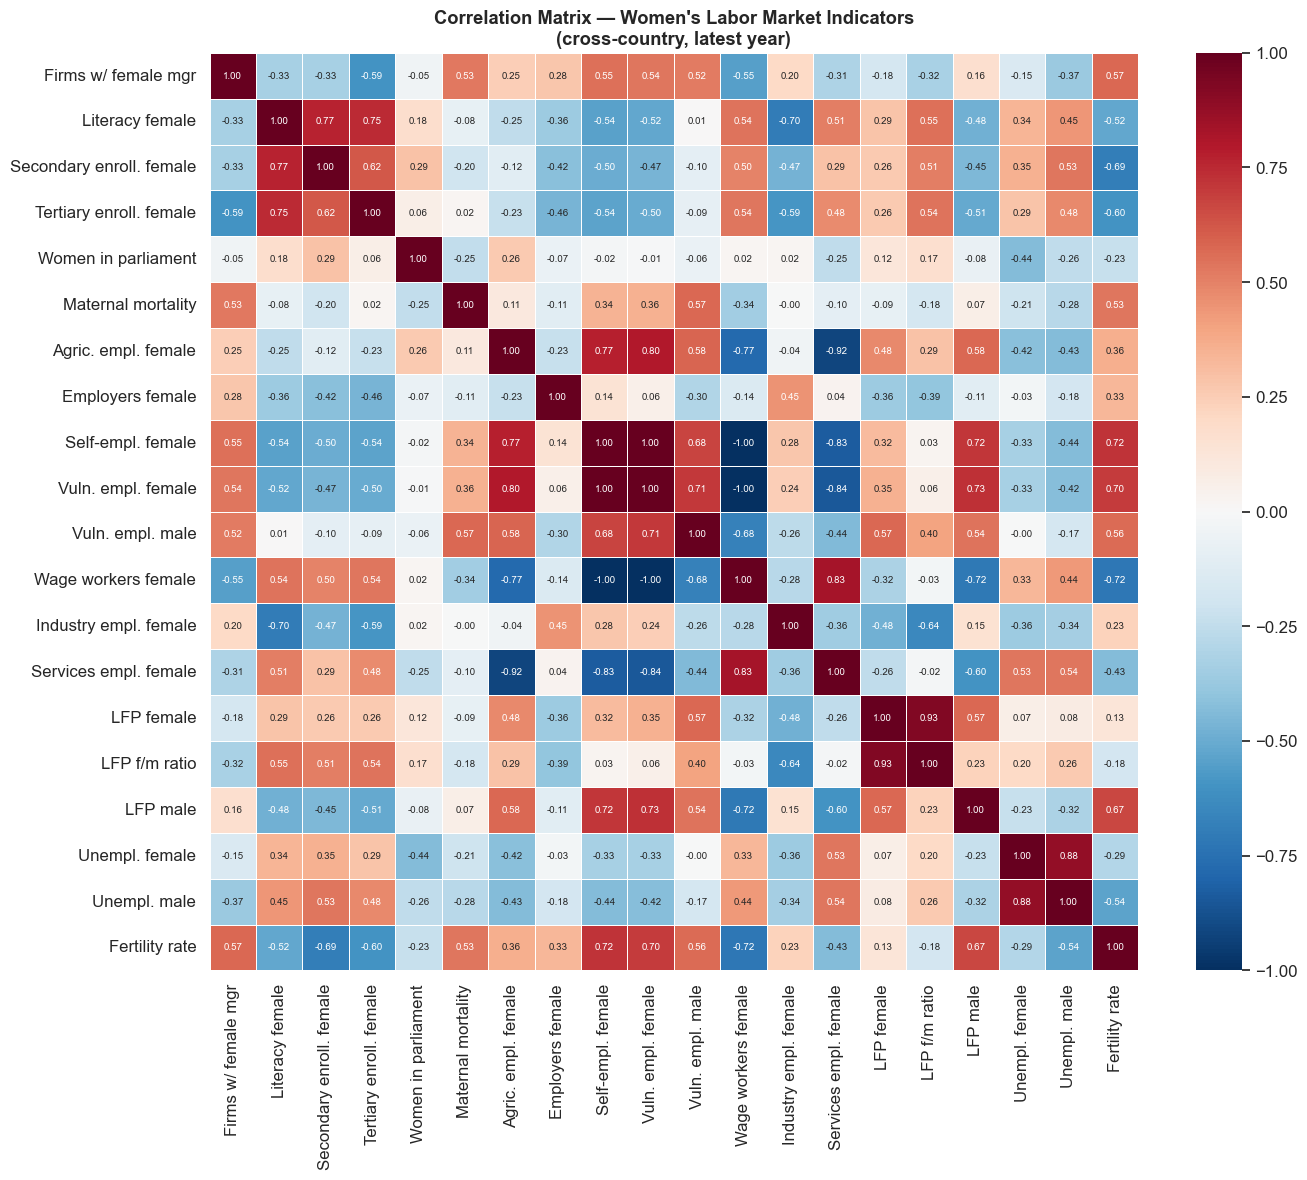

In [22]:
# Short names for readability in the heatmap
short_names = {
    "SL.TLF.CACT.FE.ZS": "LFP female",
    "SL.TLF.CACT.MA.ZS": "LFP male",
    "SL.TLF.CACT.FM.ZS": "LFP f/m ratio",
    "SL.UEM.TOTL.FE.ZS": "Unempl. female",
    "SL.UEM.TOTL.MA.ZS": "Unempl. male",
    "SL.EMP.VULN.FE.ZS": "Vuln. empl. female",
    "SL.EMP.VULN.MA.ZS": "Vuln. empl. male",
    "SL.EMP.SELF.FE.ZS": "Self-empl. female",
    "SL.EMP.MPYR.FE.ZS": "Employers female",
    "SL.EMP.WORK.FE.ZS": "Wage workers female",
    "SL.AGR.EMPL.FE.ZS": "Agric. empl. female",
    "SL.IND.EMPL.FE.ZS": "Industry empl. female",
    "SL.SRV.EMPL.FE.ZS": "Services empl. female",
    "SE.ADT.LITR.FE.ZS": "Literacy female",
    "SE.SEC.ENRR.FE":    "Secondary enroll. female",
    "SE.TER.ENRR.FE":    "Tertiary enroll. female",
    "SP.DYN.TFRT.IN":    "Fertility rate",
    "SH.STA.MMRT":       "Maternal mortality",
    "SG.GEN.PARL.ZS":    "Women in parliament",
    "IC.FRM.FEMM.ZS":    "Firms w/ female mgr",
}

# Use df_wide which already has the latest-year pivot
corr_df = df_wide.set_index("country_code").drop(columns=["country_name"])
corr_df = corr_df.rename(columns=short_names)
corr_matrix = corr_df.corr()

mask = corr_matrix.isnull()  # hide pairs with no overlap
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.4,
    ax=ax,
    annot_kws={"size": 7},
    vmin=-1, vmax=1,
)
ax.set_title("Correlation Matrix — Women's Labor Market Indicators\n(cross-country, latest year)", fontweight="bold")
plt.tight_layout()
plt.show()